# Heart Stroke Prediction: Handling Missing Values

**See Run Results :** [https://dagshub.com/Rahul-404/heart-stroke-prediction.mlflow](https://dagshub.com/Rahul-404/heart-stroke-prediction.mlflow/#/)

In [1]:
# TRIGGER_FLAG: run
# KAGGLE_CONFIG: enable_gpu = false
# KAGGLE_CONFIG: enable_tpu = false
# KAGGLE_CONFIG: keywords = ["healthcare", "classification", "data cleaning"]
# KAGGLE_CONFIG: dataset_sources = ["rahulshelke98/healthcare-data-stroke-dataset"]
# KAGGLE_CONFIG: kernel_sources = ["rahulshelke98/01-02-data-quality-correction"]

## Required Installtion

In [ ]:
import os
import sys

# Check if running in Kaggle Cloud Environment
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    print("--- Kaggle Environment Detected: Installing Cloud Dependencies ---")
    # 1. Install general cloud dependencies
    os.system(f"{sys.executable} -m pip install -q mlflow dagshub")
    
    # 2. Clone the specific branch of the repository
    print("Cloning repository...")
    # os.system("git clone -b feat/notebooks https://github.com/Rahul-Shelke-1/heart-stroke-risk-stratification.git")
    os.system(f"{sys.executable} -m pip install -q git+https://github.com/Rahul-Shelke-1/heart-stroke-risk-stratification.git@feat/notebooks")
    
else:
    print("--- Local/Non-Kaggle Environment Detected: Skipping Installation ---")
    # Local packages should ideally be pre-managed via your local uv environment

--- Local/Non-Kaggle Environment Detected: Skipping Installation ---


## Smart Environment Detection & Secrets Setup

In [ ]:
import os
import mlflow
from dotenv import load_dotenv

# 1. Safely retrieve credentials from Kaggle's internal secure vault
try:
    # 1. Detect if running inside Kaggle's container
    IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

    if IS_KAGGLE:
        DAGSHUB_USERNAME = os.environ.get("DAGSHUB_USERNAME")
        DAGSHUB_TOKEN = os.environ.get("DAGSHUB_TOKEN")
    else:
        load_dotenv()
        DAGSHUB_USERNAME = os.environ.get("DAGSHUB_USERNAME", "Rahul-404")
        DAGSHUB_TOKEN = os.environ.get("DAGSHUB_TOKEN")
    
    # Replace this with your actual DagsHub repo name
    REPO_NAME = "heart-stroke-prediction"
    
    # 2. Inject environment variables that the MLflow client natively looks for
    os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
    os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN
    
    # 3. Set the remote tracking URI to point to DagsHub
    tracking_uri = f"https://dagshub.com/{DAGSHUB_USERNAME}/{REPO_NAME}.mlflow"
    mlflow.set_tracking_uri(tracking_uri)
    
    print("Successfully connected to DagsHub MLflow tracking server!")
except Exception as e:
    # print(f"Local or non-Kaggle execution environment detected: {e}")
    print(f"Error establishing MLflow/DagsHub context: {e}")

--- PATH SUMMARY ---
Execution Target: Local Machine
Reading Input From: /Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks/data
Writing Outputs To: /Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks/artifact


## Unified Path Setup Strategy

In [ ]:
import os
from pathlib import Path

# 1. Reuse your environment checker flag
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

# 2. Define your repository name to map Kaggle input paths perfectly
KAGGLE_USER = os.environ.get("KAGGLE_USER")  # Replace with your actual lowercase Kaggle username
DATASET_SLUG = os.environ.get("KAGGLE_DATASET_NAME")  # Replace with your Kaggle dataset slug

if IS_KAGGLE:
    # --- KAGGLE CLOUD PATH CONTEXT ---
    # Kaggle mounts your datasets under /kaggle/input/YOUR_DATASET_SLUG
    INPUT_DIR = Path(f"/kaggle/input/datasets/{KAGGLE_USER}/{DATASET_SLUG}")

    if not INPUT_DIR.exists():
        raise f"Input Directory not sxists: {INPUT_DIR}"
    
    # Kaggle strictly allows file writing ONLY inside /kaggle/working
    OUTPUT_DIR = Path("/kaggle/working/artifacts")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    if not OUTPUT_DIR.exists():
        raise f"Output Directory not sxists: {OUTPUT_DIR}"
else:
    # --- LOCAL ENVIRONMENT PATH CONTEXT ---
    current_directory = Path.cwd()
    # Points to your local repository structure (e.g., repository_root/data/)
    INPUT_DIR = Path(current_directory, "notebooks", "data")
    
    if not INPUT_DIR.exists():
        raise f"Input Directory not sxists: {INPUT_DIR}"

    # Keeps your local repo clean by saving local run artifacts into an outputs folder
    OUTPUT_DIR = Path(current_directory, "notebooks", "artifact")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("--- PATH SUMMARY ---")
print(f"Execution Target: {'Kaggle Cloud' if IS_KAGGLE else 'Local Machine'}")
print(f"Reading Input From: {INPUT_DIR}")
print(f"Writing Outputs To: {OUTPUT_DIR}")

### Library version problem

In [4]:
import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns


from sklearn import set_config
set_config(transform_output="pandas", display="diagram")

print("Seaborn version: ",sns.__version__)
print("Numpy version: ",np.__version__)
print("Matplotlib version: ",matplotlib.__version__)

# Seaborn version:  0.12.2 # this gives bar plot color, but heatmap have error
# Numpy version:  1.24.4
# Seaborn version:  0.13.0 # this gives bar plot no color , but heatmap no error solved

# matplot version : 3.7.3
# 3 solves all the problems

Seaborn version:  0.13.2
Numpy version:  2.4.6
Matplotlib version:  3.10.9


## Importing Libraries

In [5]:
from heart_stroke_prediction.analyze.basic_data_inspection import (DataInspector,
                                               DataTypesInspectionStrategy,
                                               SummaryStatisticsInspectionStrategy,
                                               )

# univsriate analysis

# bivariate analysis

# missing values handling
from heart_stroke_prediction.analyze.missing_values.describe import MissingDescriber
from heart_stroke_prediction.analyze.missing_values.visualize import MissingVisualizer
from heart_stroke_prediction.analyze.missing_values.handler import MissingImputer

import cloudpickle

from sklearn.pipeline import Pipeline

# setting config
from sklearn import set_config
set_config(transform_output="pandas")

# data manupulation
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## I/O Paths

In [6]:
DATA_FILES = os.listdir(INPUT_DIR)
DATA_FILES

['healthcare-dataset-stroke-data.csv']

In [7]:
ARTIFACT_FILES = os.listdir(OUTPUT_DIR)
ARTIFACT_FILES

['missing_imputer_validation_pipeline.pkl',
 'data_correction_pipeline.pkl',
 'heart_stroke_data.csv',
 'missing_imputer_pipeline.pkl']

In [8]:
DATA_FILE_NAME = {
    'raw': Path(INPUT_DIR, 'healthcare-dataset-stroke-data.csv'),
    'clean': Path(OUTPUT_DIR, 'heart_stroke_data.csv'),
}

ARTIFACT_FILE_NAME = {
    'data_correct': Path(OUTPUT_DIR, 'data_correction_pipeline.pkl'),
    'handle_missing': Path(OUTPUT_DIR, 'missing_imputer_pipeline.pkl'),
    'handle_missing_val': Path(OUTPUT_DIR, 'missing_imputer_validation_pipeline.pkl'),
}

### Set Experiment Name

In [ ]:
experiment_name = "02_03_Handling_Missing_Values"
experiment_tags = {
    "experiment_type": "Classification",
    "project": "heart_stroke_risk_stratification",
    "team": "Data_Science_Core"
}

try:
    experiment_id = mlflow.create_experiment(name=experiment_name, tags=experiment_tags)
except Exception:
    # If it already exists, fetch its ID
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

# 3. Set it as the active experiment
mlflow.set_experiment(experiment_id=experiment_id)

### Set Run Name

In [ ]:
# Starts a global active run
mlflow.start_run(run_name="Handling_Missing_Values_Session")

## 2. Reading Data

**Import the CSV Data as Pandas DataFrame**

In [ ]:
with open(ARTIFACT_FILE_NAME["data_correct"], "rb") as f:
    pipeline = cloudpickle.load(f)

In [12]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('correct_column_names', ...), ('correct_column_values', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mapping,{'Residence_type': 'residence_type'}
,column_mappings,"{'ever_married': {'No': 'no', 'Yes': 'yes'}, 'gender': {'Female': 'female', 'Male': 'male', 'Other': 'other'}, 'residence_type': {'Rural': 'rural', 'Urban': 'urban'}, 'smoking_status': {'Unknown': 'unknown', 'formerly smoked': 'formerly_smoked', 'never smoked': 'never_smoked'}, ...}"
,missing_tokens,['unknown']
,threshold,1
,action,'drop'
,fill_value,'other'


In [ ]:
df = pipeline.fit_transform(pd.read_csv(DATA_FILE_NAME['raw']))

### **Show Top 5 Records**

In [14]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


In [15]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,female,80.0,1,0,yes,private,urban,83.75,NaN,never_smoked,0
5106,44873,female,81.0,0,0,yes,self_employed,urban,125.20,40.0,never_smoked,0
5107,19723,female,35.0,0,0,yes,self_employed,rural,82.99,30.6,never_smoked,0
5108,37544,male,51.0,0,0,yes,private,rural,166.29,25.6,formerly_smoked,0
5109,44679,female,44.0,0,0,yes,govt_job,urban,85.28,26.2,NaN,0


### **Feature Information**

- Here we used the heart stroke dataset that is available in the kaggle website for our analysis. This datasets consists of total 12 attributes. The complete description of the attributes used in the proposed work is given below.

- **id**: This attribute means person's id. it's numerical data.

- **Age**: This attribute means a persons age. it's numerical data.

- **Gender**: This attribute means a person's gender, it's categorical data.

- **Hypertension**: This attribute means that this person is hypertensive or not. it's numerical data.

- **work type**: This attribute represents the person work scenario. it's categorical data.

- **residence type**: This attribute represnts the person work scenario. it's categorical data.

- **heart disease**: This attribute means wheather this person has a heart disease person or not. it's numerical data.

- **avg_glucose_level**: This attribute means what was the level of a person's glucose condition. it's numercial data.

- **Bmi**: This attribute represents a person's married status. it's categorical data.

- **ever_married**: This attribute represents a person's married status. it's categorical data.

- **smoking_status**: This attribute means a person's smoking condition. it's categorical data.

- **Stroke**: This attribute means a person previously had a choise or not.

### **Shape of the dataset**

In [16]:
df.shape

(5109, 12)

In [17]:
inspector = DataInspector(DataTypesInspectionStrategy())
inspector.execute_inspection(df)


Data Types and Non-null Counts:
<class 'pandas.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5109 non-null   int64  
 1   gender             5109 non-null   str    
 2   age                5109 non-null   float64
 3   hypertension       5109 non-null   int64  
 4   heart_disease      5109 non-null   int64  
 5   ever_married       5109 non-null   str    
 6   work_type          5109 non-null   str    
 7   residence_type     5109 non-null   str    
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4908 non-null   float64
 10  smoking_status     3565 non-null   str    
 11  stroke             5109 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 666.9 KB
None


### **Summary of the dataset**

In [18]:
inspector.set_strategy(SummaryStatisticsInspectionStrategy())
inspector.execute_inspection(df)


Summary Statistics (Numerical Features):
                 id          age  hypertension  heart_disease  \
count   5109.000000  5109.000000   5109.000000    5109.000000   
mean   36513.985516    43.229986      0.097475       0.054022   
std    21162.008804    22.613575      0.296633       0.226084   
min       67.000000     0.080000      0.000000       0.000000   
25%    17740.000000    25.000000      0.000000       0.000000   
50%    36922.000000    45.000000      0.000000       0.000000   
75%    54643.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level         bmi       stroke  
count        5109.000000  4908.00000  5109.000000  
mean          106.140399    28.89456     0.048738  
std            45.285004     7.85432     0.215340  
min            55.120000    10.30000     0.000000  
25%            77.240000    23.50000     0.000000  
50%            91.880000    28.10000     0.000000  
75%     

In [19]:
# visualize target

### **Statistical Inferences**

- Median age of population is 43 years.
- 25% of the population is aged below 25
- Another 25% is aged above 60 and remaining in between threse ages
- About 9.7% and 5.4% of population suffers from hypertension with heart disease respectively.
- People with higher BMI (BMI > 45) are less represented. This can affect our machine learning models significantly.

## **Correcting feature categarization :**

In [20]:
TARGET_COL = ["stroke"]
ID_COL = ["id"]
# TEXT_FEATURES = ["Name"]
CAT_FEATURES = [col for col in df.columns if df[col].dtype == "O" if col not in TARGET_COL+ID_COL]
NUM_FEATURES = [col for col in df.columns if df[col].dtype != "O" if col not in TARGET_COL+ID_COL]

In [21]:
print("id column: ", ID_COL)
print("target column: ", TARGET_COL)
print("categorical columns: ", CAT_FEATURES)
print("numerical columns: ", NUM_FEATURES)

id column:  ['id']
target column:  ['stroke']
categorical columns:  []
numerical columns:  ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']


In [22]:
TARGET_COL = ["stroke"]
ID_COL = ["id"]
CAT_FEATURES = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
NUM_FEATURES = ['age', 'avg_glucose_level', 'bmi']

# 3. **Missing Value Check :**

In [23]:
# describe missing values
describe = MissingDescriber(df)

# visualize missing values
visualize = MissingVisualizer(df)

# impute missing values
impute = MissingImputer(df)

In [24]:
describe.get_missing_report()

,Missing Count,Percentage (%)
smoking_status,1544,30.221178
bmi,201,3.934234


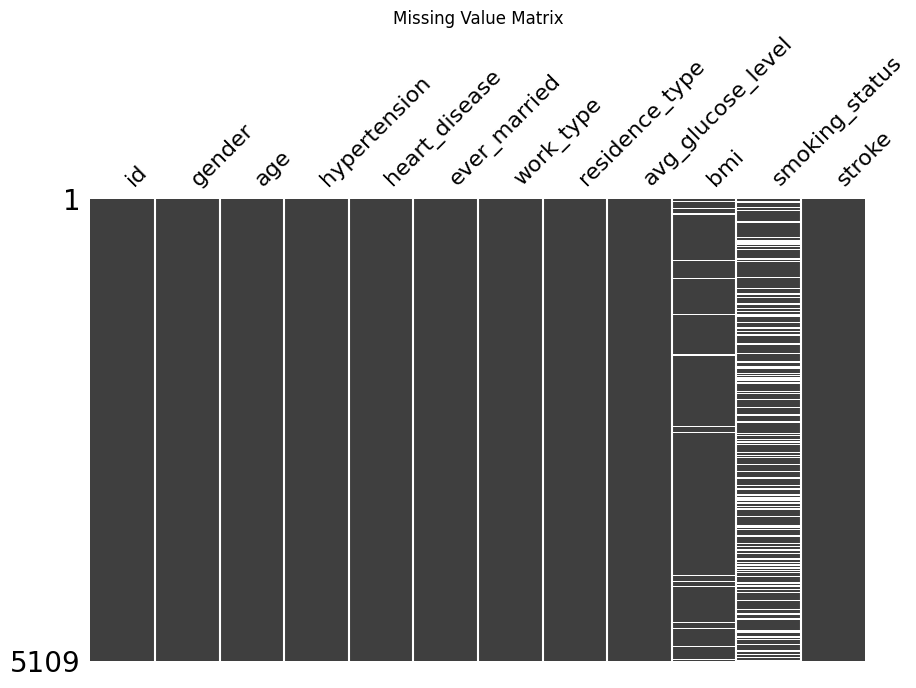

In [25]:
visualize.plot_missing_matrix()

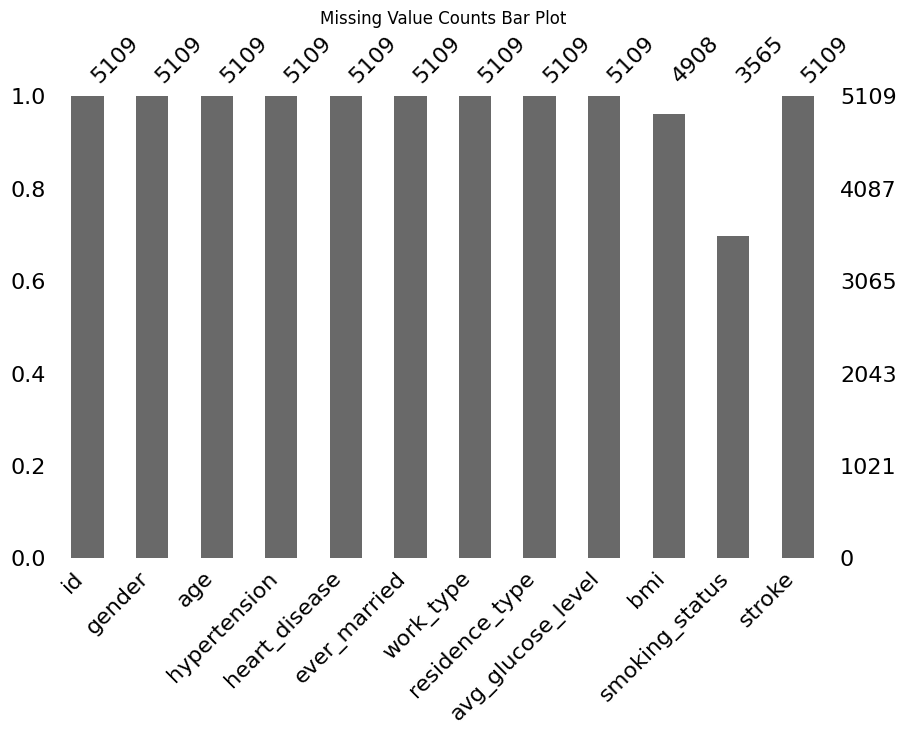

In [26]:
visualize.plot_missing_barplot()

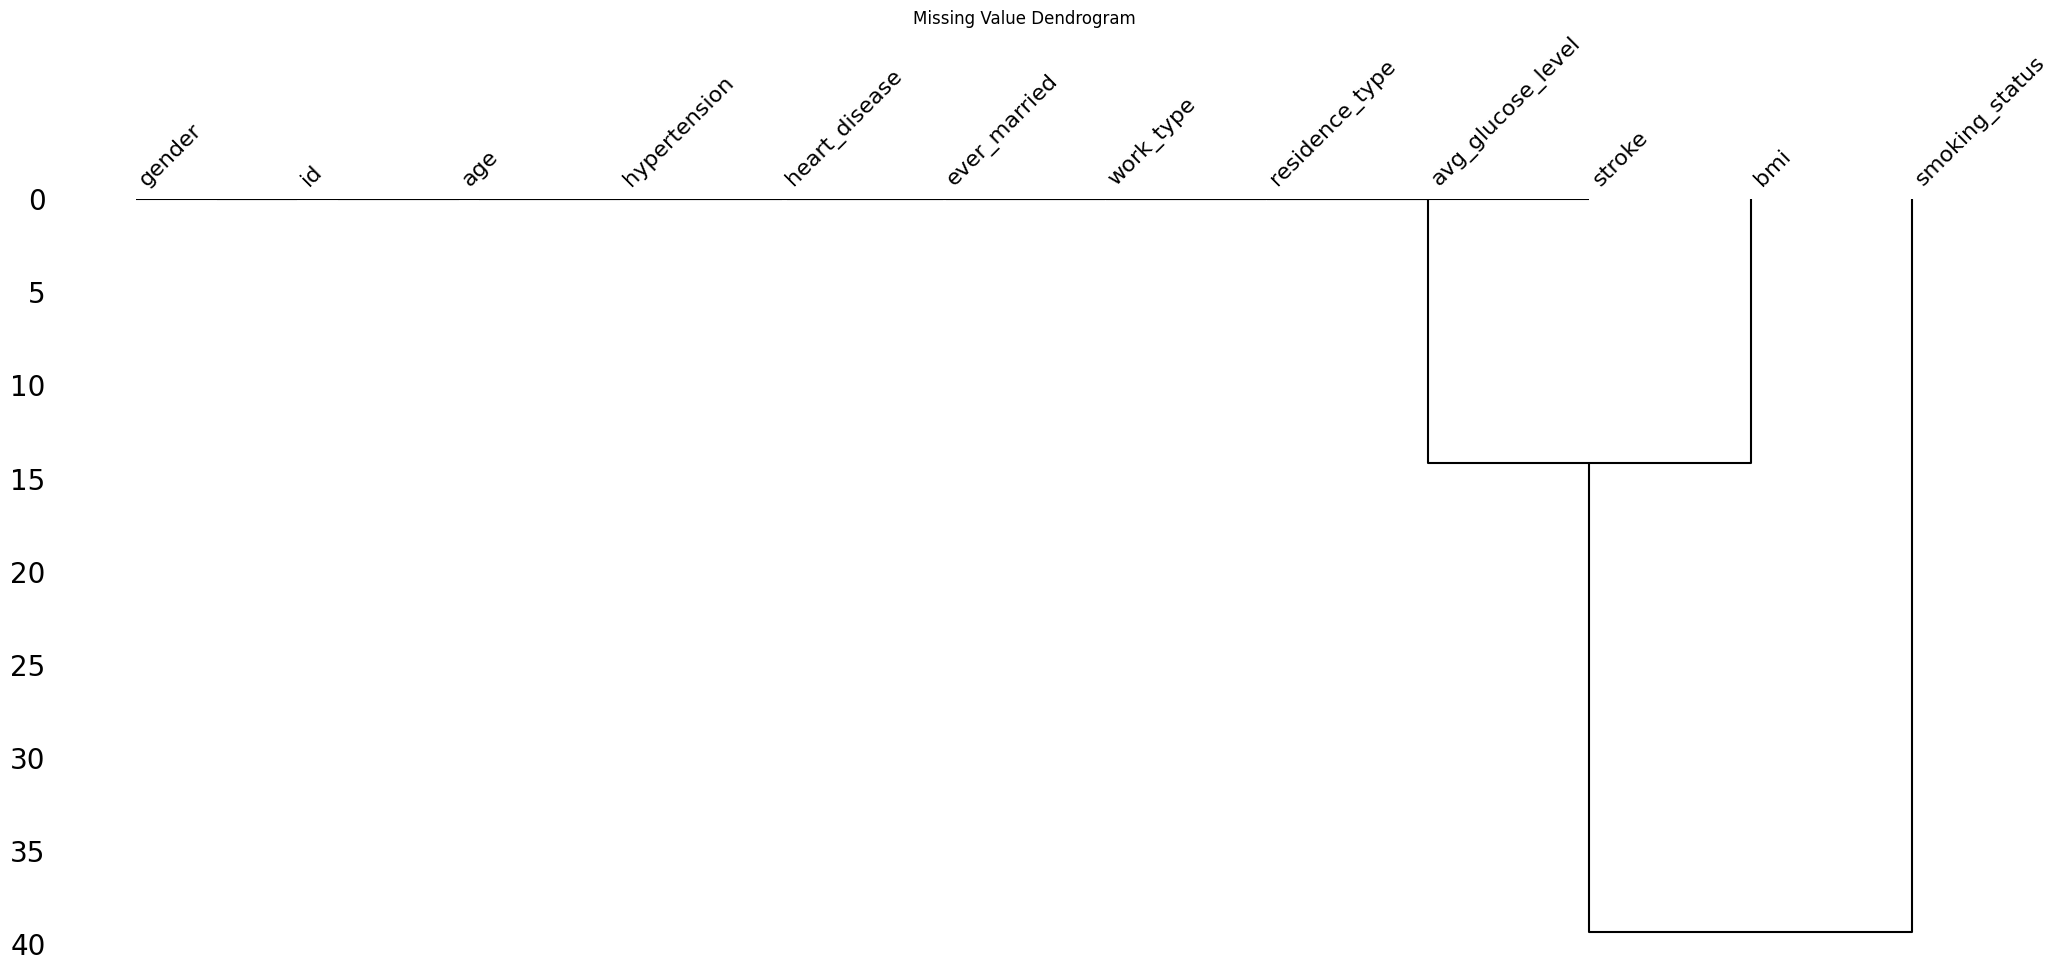

In [27]:
visualize.plot_missing_dendrogram()

- The dendrogram allows you to more fully correlate variable completion, revealing trends deeper than the pairwise ones visible in the correlation heatmap.

- The dendrogram uses a hierarchical clustering algorithm (courtesy of scipy) to bin variables against one another by their nullity correlation (measured in terms of binary distance).

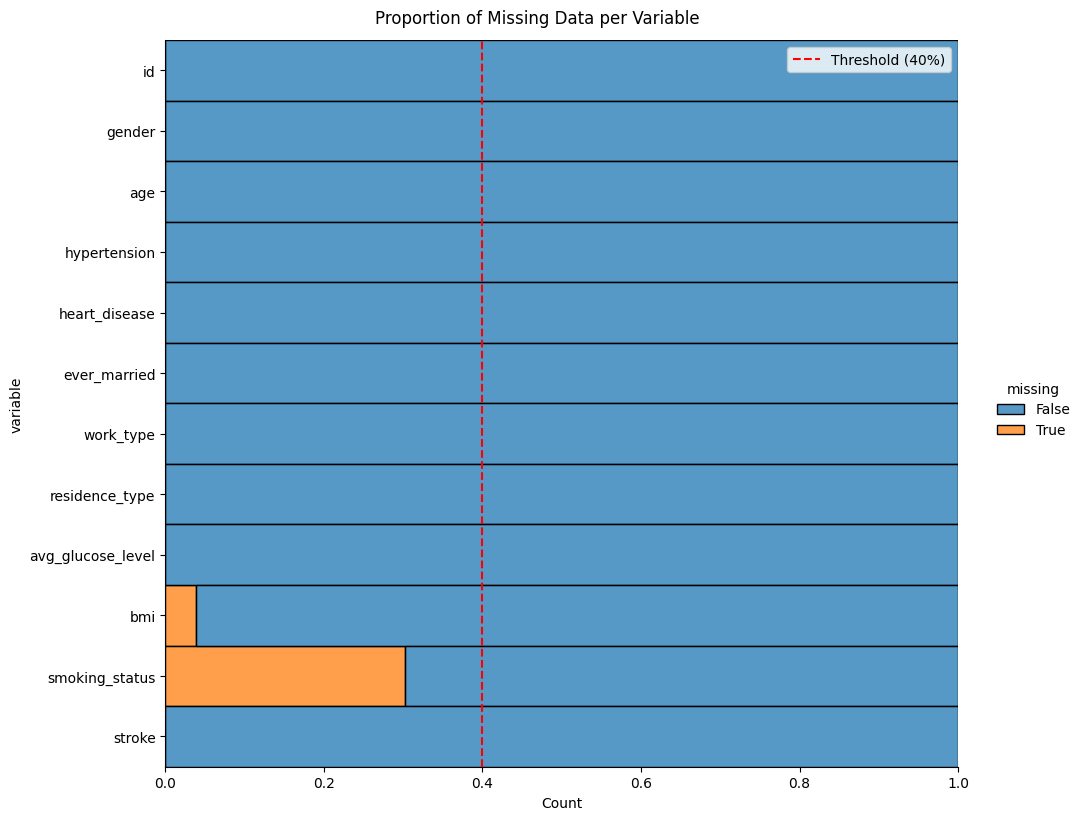

In [28]:
visualize.plot_missing_frequency_displot()

- Around 4% of the BMI data is missing in the dataset
- Smoking habit information is missing for 30% of the population

# 4. Missing Value Analysis



Let's try to identify why ?

- MNAR: missing due to value it self
    - BMI is missing because the patient felt their weight was too high or too low to disclose.
    - Smoking status is missing because heavy smokers or individuals who perceive their habit as a health risk—especially those already managing **hypertension—intentionally** withheld their information to avoid medical or social judgment, meaning the missingness is directly caused by the **actual value** (smoking) being hidden.

- MAR: missing due to other variable
    - BMI is missing for elderly patients because the clinic's standard procedure for patients over 80 doesn't always require a weigh-in.
    - Individuals may conceal their **smoking status** due to the social stigma surrounding **minors** and **females** smoking, or because their **work type** and **residence** create professional and community pressures, especially when managing health conditions like **hypertension**.

- MCAR: really missing
    - BMI is missing because the weighing scale battery died for a few random patients.
    - Smoking status information is missing for some individuals because a **technical glitch** in the digital survey randomly failed to save certain responses, or a **batch of paper questionnaires** containing those records was accidentally lost in transit, independent of the participant's age, gender, or health conditions

## **Missing Not At Random:**

Consult with doctors or researchers who collect this kind of data. We have to ask them directly: "Are patients with high or low BMIs known to avoid reporting their weight?" They will likely confirm this bias exists (meaning it's likely MNAR).

**Limitation:** No access to data lineage or SME for conclusion

## **Missing Completely At Random:**

In [29]:
related_cols = ['age', 'avg_glucose_level', 'gender', 'hypertension', 
                'heart_disease', 'ever_married', 'work_type', 'residence_type']

## BMI

### **visual evidence**

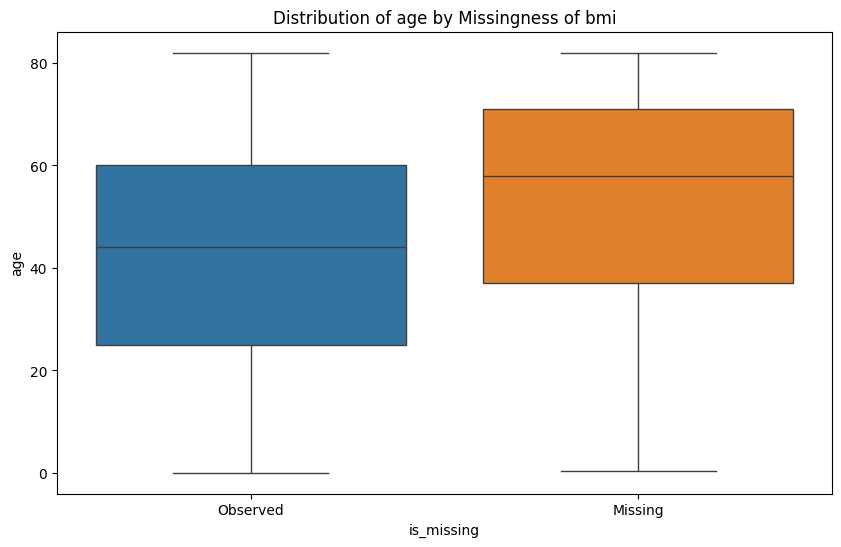

In [30]:
visualize.plot_comparison_by_missingness('bmi', 'age')

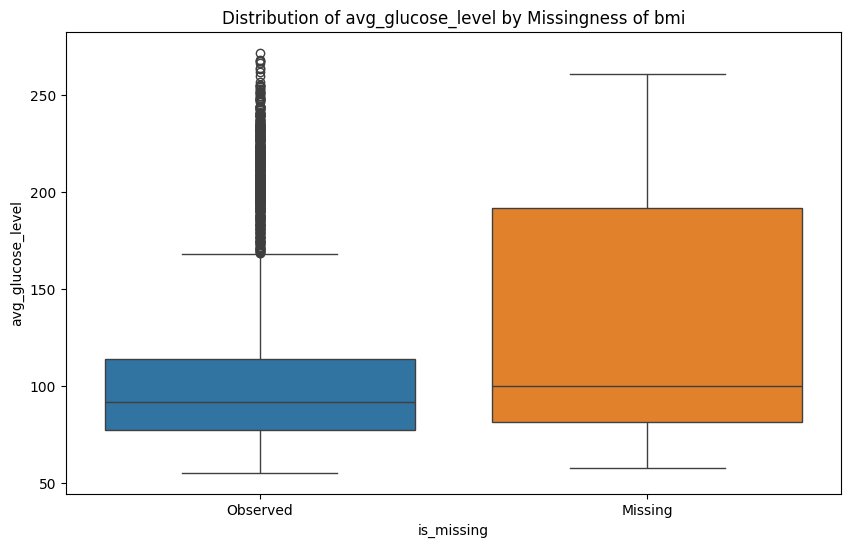

In [31]:
visualize.plot_comparison_by_missingness('bmi', 'avg_glucose_level')

In [32]:
# visualize.plot_comparison_by_missingness('bmi', 'gender', 'stacked_percent_bar')

- gender don't show significant difference

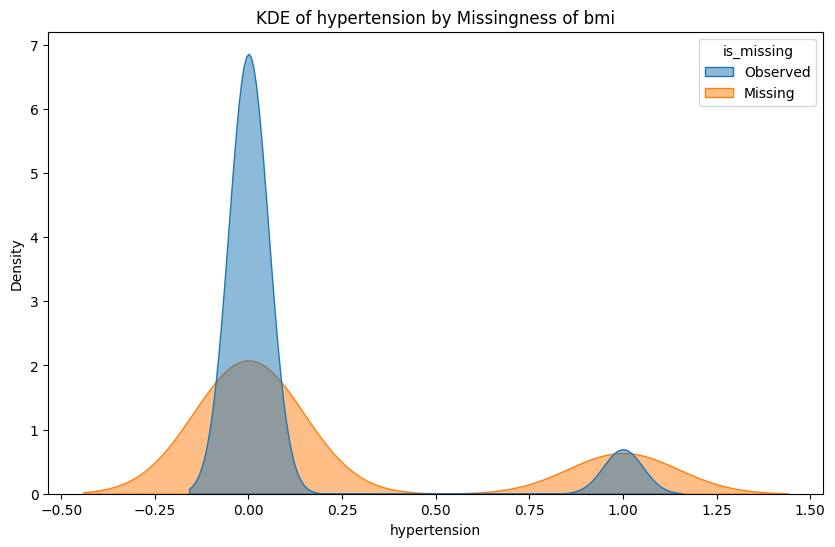

In [33]:
visualize.plot_comparison_by_missingness('bmi', 'hypertension', 'kde')

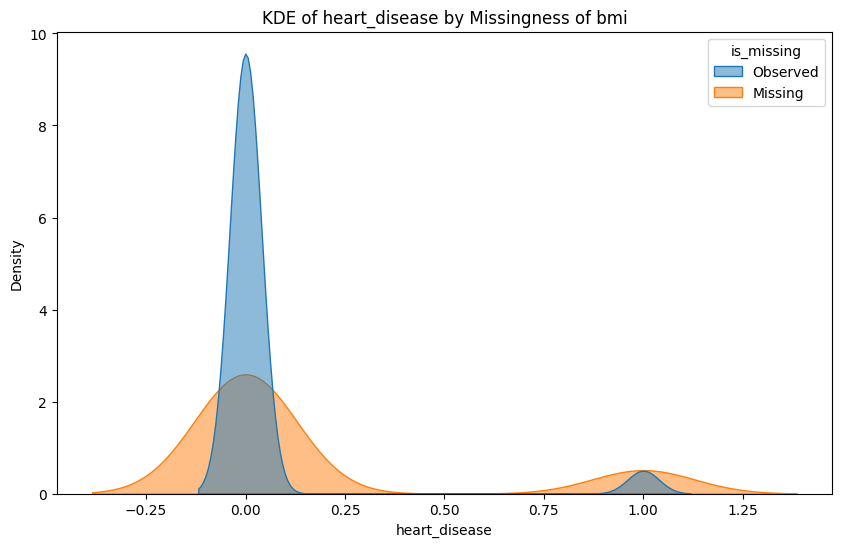

In [34]:
visualize.plot_comparison_by_missingness('bmi', 'heart_disease', 'kde')

In [35]:
# visualize.plot_comparison_by_missingness('bmi', 'ever_married', 'stacked_percent_bar')

- marrige don't show significant difference

In [36]:
visualize.plot_comparison_by_missingness('bmi', 'work_type', 'stacked_percent_bar')

Unsupported dtype for work_type.


<Figure size 1000x600 with 0 Axes>

In [37]:
# visualize.plot_comparison_by_missingness('bmi', 'residence_type', 'stacked_percent_bar')

- residence don't show significant difference

### **statistical evidence**

In [38]:
related_cols = ['age', 'avg_glucose_level', 'gender', 'hypertension', 
                'heart_disease', 'ever_married', 'work_type', 'residence_type']

**BMI**

In [39]:
describe.classify_missingness_mcar_mar("bmi", related_cols)


--- Testing MCAR/MAR for 'bmi' against 8 related columns ---


,Related Column,Test Used,P-value,Conclusion
0,age,Independent T-test,0.0,MAR (Dependent/Related)
1,avg_glucose_level,Independent T-test,0.0,MAR (Dependent/Related)
3,hypertension,Independent T-test,0.0,MAR (Dependent/Related)
4,heart_disease,Independent T-test,0.0,MAR (Dependent/Related)
2,gender,N/A,NaN,Cannot test
5,ever_married,N/A,NaN,Cannot test
6,work_type,N/A,NaN,Cannot test
7,residence_type,N/A,NaN,Cannot test


## **Smoking Status**

### **visual evidence**

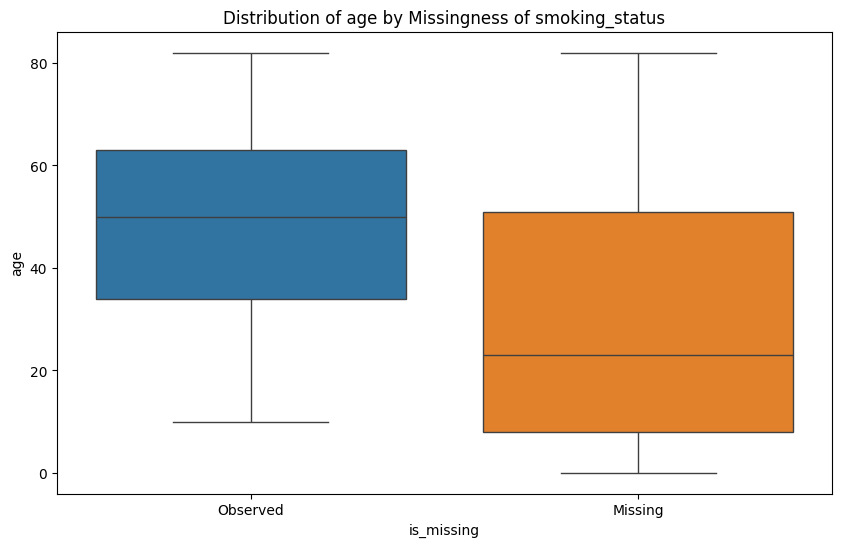

In [40]:
visualize.plot_comparison_by_missingness('smoking_status', 'age')

- diagram says, data is missing about smoking status for minors and adults.

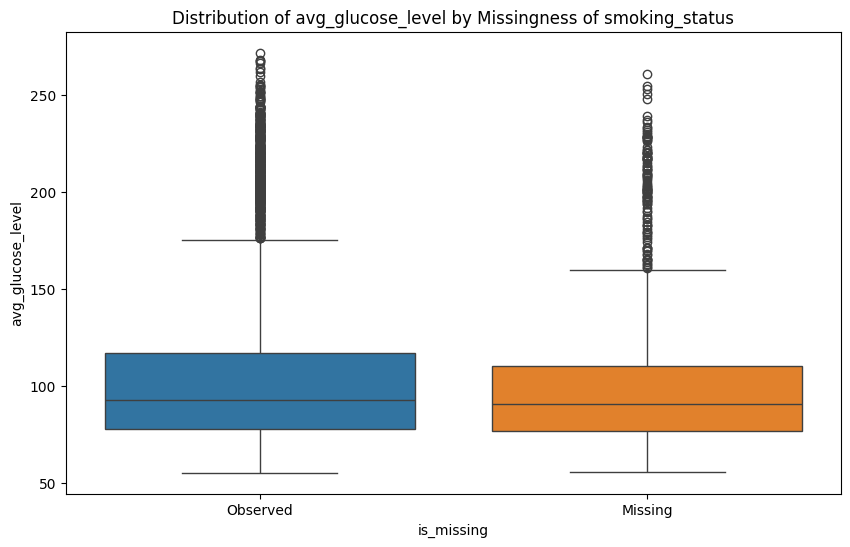

In [41]:
visualize.plot_comparison_by_missingness('smoking_status', 'avg_glucose_level')

In [42]:
visualize.plot_comparison_by_missingness('smoking_status', 'gender', 'stacked_percent_bar')

Unsupported dtype for gender.


<Figure size 1000x600 with 0 Axes>

- gender don't show significant difference

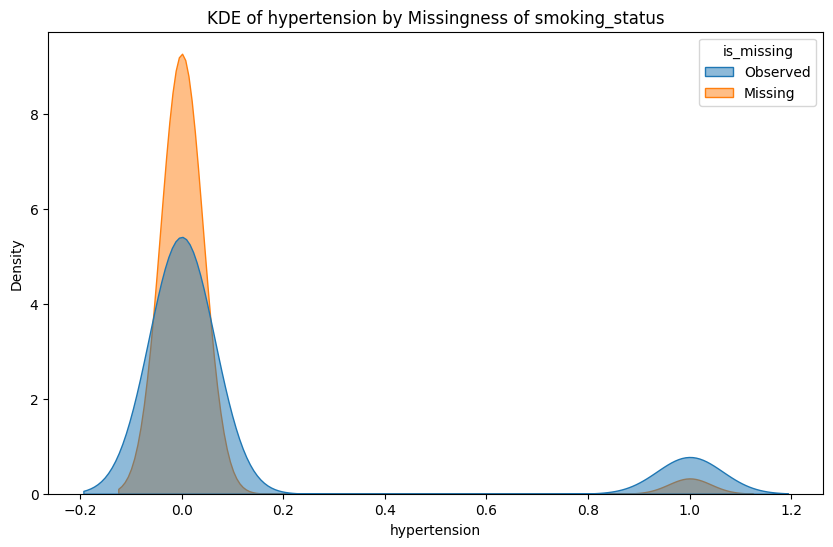

In [43]:
visualize.plot_comparison_by_missingness('smoking_status', 'hypertension', 'kde')

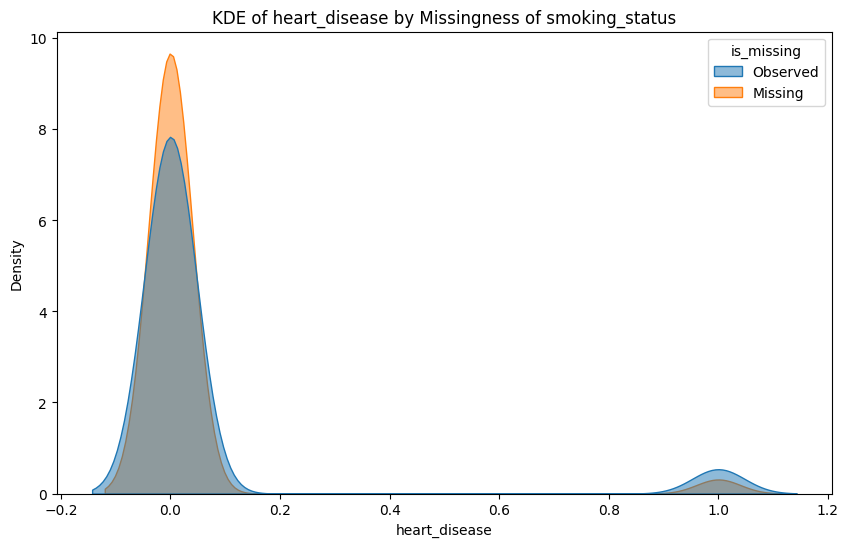

In [44]:
visualize.plot_comparison_by_missingness('smoking_status', 'heart_disease', 'kde')

In [45]:
visualize.plot_comparison_by_missingness('smoking_status', 'ever_married', 'stacked_percent_bar')

Unsupported dtype for ever_married.


<Figure size 1000x600 with 0 Axes>

- **unmarried patients** are not exposing their smoking status

In [46]:
visualize.plot_comparison_by_missingness('smoking_status', 'work_type', 'stacked_percent_bar')

Unsupported dtype for work_type.


<Figure size 1000x600 with 0 Axes>

- **90% of childrens** hiding their smoking status
- **36%** of patients who never worked also hiding smoking status 

In [47]:
visualize.plot_comparison_by_missingness('smoking_status', 'residence_type', 'stacked_percent_bar')

Unsupported dtype for residence_type.


<Figure size 1000x600 with 0 Axes>

- no difference based on **residence** in which patients are living

### **Smoking Status**

In [48]:
describe.classify_missingness_mcar_mar("smoking_status", related_cols)


--- Testing MCAR/MAR for 'smoking_status' against 8 related columns ---


,Related Column,Test Used,P-value,Conclusion
0,age,Independent T-test,0.0,MAR (Dependent/Related)
1,avg_glucose_level,Independent T-test,0.0,MAR (Dependent/Related)
3,hypertension,Independent T-test,0.0,MAR (Dependent/Related)
4,heart_disease,Independent T-test,0.0,MAR (Dependent/Related)
2,gender,N/A,NaN,Cannot test
5,ever_married,N/A,NaN,Cannot test
6,work_type,N/A,NaN,Cannot test
7,residence_type,N/A,NaN,Cannot test


## Little's MCAR

In [49]:
# !pip install -q pyampute

In [50]:
# describe.final_missingness_conclusion("bmi", related_cols)

In [51]:
# describe.final_missingness_conclusion("smoking_status", related_cols)

In [52]:
# describe.run_littles_mcar_test(["smoking_status"])

In [53]:
# describe.run_littles_mcar_test(["bmi"])

## Inference:

- except `residence_type`, rest data suggests that missing data show significant difference in missingness

- data suggests `bmi` and `smoking_status` are likely to be **MAR**, means there are other things affecting the missingness

# 5. **Imputing Missing At Random:**

Approach:

- `bmi`: numerical feature
    1. dropnull
    2. mean
    3. median
    4. knn
    5. iterative - RandomForestRegressor

- `smoking_status`: nominal feature
    1. dropnull
    2. constant
    3. most frequent

- managable combinations : 4 x 2 = 8

- Metrics:
    1. Recall
    2. PR-AUC
    3. Balanced Accuracy
    4. F2-score
    5. Calibration

Baseline : Dropnull + median + constant

In [54]:
# 1. drop null
# 2. median-constant

# 3. mean-mode
# 4. median-mode
# 5. knn-mode
# 6. iterative-regressor-mode

# 7. mean-iterative-classifier
# 8. median-iterative-classifier
# 9. knn-iterative-classifier
# 10. iterative-regressor-iterative-classifier

In [55]:
from sklearn.ensemble import RandomForestRegressor
from imblearn.ensemble import BalancedRandomForestClassifier

# To use the experimental IterativeImputer, we need to explicitly ask for it:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import cloudpickle

# pipeline
from sklearn.compose import ColumnTransformer
# plto
import matplotlib.pyplot as plt
import numpy as np

In [56]:


def plot_missing_champions(y_labels: list, mean_score_data: np.ndarray, stds_data: np.ndarray, x_label:str, feature_with_missing:str):
    # --- 1. Required Data Definitions ---
    # x_labels = ["Full Data", "Mean", "Median", "Most Freq", "Iterative"]
    # mses_diabetes = np.array([2800, 3100, 3050, 3200, 2900])
    # stds_data = np.array([150, 200, 180, 210, 160])
    colors = ["r", "g", "b", "orange", "black", "purple", "cyan", "magenta", "yellow", "brown"]

    # --- 2. Executable Plotting Code ---
    plt.figure(figsize=(8, 6)) # Single figure, no subplots

    # Plotting all bars at once using arrays
    plt.barh(
        np.arange(len(mean_score_data)),
        mean_score_data,
        xerr=stds_data,
        color=colors,
        alpha=0.6,
        align="center",
    )

    # Formatting
    plt.title(f"Imputation Techniques with {feature_with_missing}")
    plt.xlabel(f"{x_label}")
    plt.yticks(np.arange(len(mean_score_data)), y_labels)

    # Match your specific styling constraints
    plt.xlim(left=np.min(mean_score_data) * 0.9, right=np.max(mean_score_data) * 1.1)
    plt.gca().invert_yaxis() # Puts the first label at the top

    plt.tight_layout()
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    plt.show()

### Load Raw Data

In [ ]:
df = pd.read_csv(DATA_FILE_NAME['raw'])

df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


### Evaluation Function

In [58]:
# num_imputers
base_regressor = RandomForestRegressor(
                n_estimators=10,
                max_depth=20,
                min_samples_leaf=1,
                n_jobs=-1,
                random_state=42
            )
num_mean_imputer = SimpleImputer(strategy="mean", add_indicator=True)
num_median_imputer = SimpleImputer(strategy="median", add_indicator=True)
num_knn_imputer = KNNImputer(add_indicator=True)
num_iter_imputer = IterativeImputer(estimator=base_regressor, max_iter=10, random_state=42, add_indicator=True)

# cat_imputers
cat_const_imputer = SimpleImputer(strategy="constant", missing_values=np.nan, fill_value='missing', add_indicator=True)
cat_mode_imputer = SimpleImputer(strategy="most_frequent", add_indicator=True)

In [59]:
N_SPLITS = 5

def get_score(X, y, num_features, cat_features, scoring='f1', num_imputer=None, cat_imputer=None):

    numerical_pipeline = Pipeline(
        steps=[
            # handle missing
            ('imputer', num_imputer),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            # handle missing
            ('imputer', cat_imputer),
            # encode features
            ("onehot_encoder", OneHotEncoder(
                                sparse_output=False, 
                                min_frequency=5,
                                handle_unknown='ignore',
                                drop='if_binary'
                            )),
        ]
    )

    model = BalancedRandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            sampling_strategy="auto",
            random_state=42,
            n_jobs=-1
        )

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    estimator = Pipeline(
        steps=[
            ('missing_imputer', ColumnTransformer(
                    transformers=[
                        ('cat', categorical_pipeline, cat_features),
                        ('num', numerical_pipeline, num_features),
                    ],
                    remainder='passthrough', # we are not passing target column
                    verbose_feature_names_out=False,
                )
            ),
            ('model', model)
        ]
    )

    scores = cross_val_score(
        estimator, X, y, scoring=scoring, cv=cv
    )
    return scores.mean(), scores.std()

y_labels = []

mean_score_data = np.zeros(9)
stds_data = np.zeros(9)

### Preprocessing Pipeline

In [ ]:
# static schema correction pipeline
with open(ARTIFACT_FILE_NAME['data_correct'], "rb" ) as f:
    pipeline = cloudpickle.load(f)

In [61]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('correct_column_names', ...), ('correct_column_values', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mapping,{'Residence_type': 'residence_type'}
,column_mappings,"{'ever_married': {'No': 'no', 'Yes': 'yes'}, 'gender': {'Female': 'female', 'Male': 'male', 'Other': 'other'}, 'residence_type': {'Rural': 'rural', 'Urban': 'urban'}, 'smoking_status': {'Unknown': 'unknown', 'formerly smoked': 'formerly_smoked', 'never smoked': 'never_smoked'}, ...}"
,missing_tokens,['unknown']
,threshold,1
,action,'drop'
,fill_value,'other'


In [62]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [63]:
pipeline.fit_transform(df).isna().sum()

id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       1544
stroke                  0
dtype: int64

### **1. Drop missing values**

In [64]:
df_composed = pipeline.fit_transform(df).dropna()

In [65]:
df_composed.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [66]:
X = df_composed.drop(['id', 'stroke'], axis=1)
y = df_composed['stroke']

In [67]:
X.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='str')

In [68]:
num_features = ['age', 'avg_glucose_level', 'bmi']
nominal_cat_features = ['work_type', 'smoking_status']
binary_cat_features = ['gender', 'ever_married', 'residence_type']
cat_features = nominal_cat_features + binary_cat_features

In [69]:
mean_score_data[0], stds_data[0] = get_score(
    X, y, num_features, cat_features, 'recall', None, None
)
y_labels.append("Drop Missing")

### **2. Replace missing values: num=mean & cat=constant**

In [70]:
df_composed = pipeline.fit_transform(df)
X = df_composed.drop('stroke', axis=1)
y = df_composed['stroke']

In [71]:
mean_score_data[1], stds_data[1] = get_score(
    X, y, num_features, cat_features, 'recall', num_mean_imputer, cat_const_imputer
)
y_labels.append("Mean-Constant Imputation")

### **3. Replace missing values: num=median & cat=constant**

In [72]:
mean_score_data[2], stds_data[2] = get_score(
    X, y, num_features, cat_features, 'recall', num_median_imputer, cat_const_imputer
)
y_labels.append("Median-Constant Imputation")

### **4. Replace missing values: num=knn & cat=constant**

In [73]:
mean_score_data[3], stds_data[3] = get_score(
    X, y, num_features, cat_features, 'recall', num_knn_imputer, cat_const_imputer
)
y_labels.append("Knn-Constant Imputation")

### **5. Replace missing values: num=iterative & cat=constant**

In [74]:
mean_score_data[4], stds_data[4] = get_score(
    X, y, num_features, cat_features, 'recall', num_iter_imputer, cat_const_imputer
)
y_labels.append("Iter-Constant Imputation")

### **6. Replace missing values: num=mean & cat=mode**

In [75]:
mean_score_data[5], stds_data[5] = get_score(
    X, y, num_features, cat_features, 'recall', num_mean_imputer, cat_mode_imputer
)
y_labels.append("Mean-Mode Imputation")

### **7. Replace missing values: num=median & cat=mode**

In [76]:
mean_score_data[6], stds_data[6] = get_score(
    X, y, num_features, cat_features, 'recall', num_median_imputer, cat_mode_imputer
)
y_labels.append("Median-Mode Imputation")

### **8. Replace missing values: num=knn & cat=mode**

In [77]:
mean_score_data[7], stds_data[7] = get_score(
    X, y, num_features, cat_features, 'recall', num_knn_imputer, cat_mode_imputer
)
y_labels.append("Knn-Mode Imputation")

### **9. Replace missing values: num=iterative & cat=mode**

In [78]:
mean_score_data[8], stds_data[8] = get_score(
    X, y, num_features, cat_features, 'recall', num_iter_imputer, cat_mode_imputer
)
y_labels.append("Iter-Mode Imputation")

## Plot the results

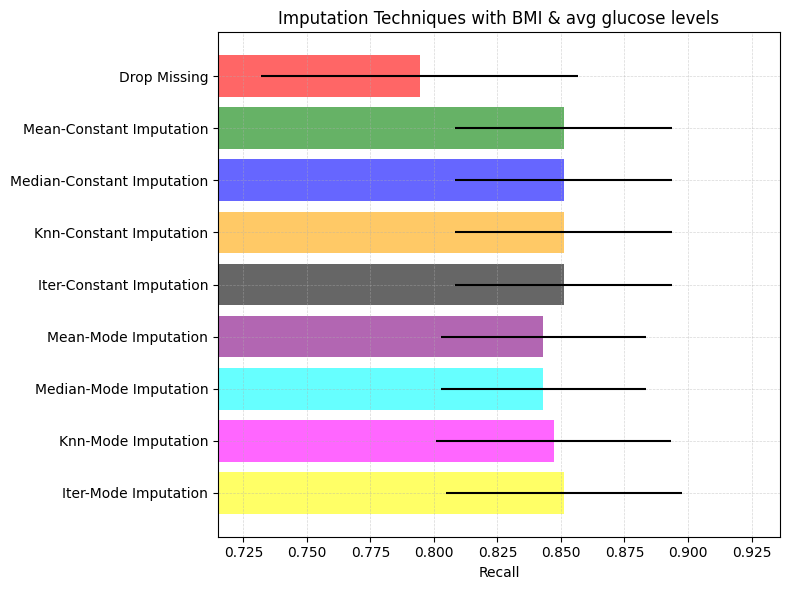

In [79]:
plot_missing_champions(y_labels, mean_score_data, stds_data, "Recall", "BMI & avg glucose levels")

**Conclusion:**

- mean-constant imputation, median-constant imputation and knn-constant imputation has given robust performance across all folds
- mean is sensitive to outliers, and knn is leazy learner
- final winner is median-constant imputation, which is not sensitive to outlier, and not leazy learner.

# 6. Finalizing Pipeline

In [80]:
numerical_pipeline = Pipeline(
        steps=[
            # handle missing
            ('imputer', num_median_imputer),
        ]
    )

categorical_pipeline = Pipeline(
        steps=[
            # handle missing
            ('imputer', cat_const_imputer),
        ]
    )

encoder = OneHotEncoder(
                    sparse_output=False, 
                    min_frequency=5,
                    handle_unknown='ignore',
                    drop='if_binary',
                    dtype=np.float64
                )

encoding_pipeline = Pipeline(
    steps=[
        # encode features
        ("onehot_encoder", 
          encoder)
    ]
)

In [ ]:
with open(ARTIFACT_FILE_NAME['data_correct'], "rb" ) as f:
    static_data_cleaning_pipeline = cloudpickle.load(f)

In [82]:
static_data_cleaning_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('correct_column_names', ...), ('correct_column_values', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mapping,{'Residence_type': 'residence_type'}
,column_mappings,"{'ever_married': {'No': 'no', 'Yes': 'yes'}, 'gender': {'Female': 'female', 'Male': 'male', 'Other': 'other'}, 'residence_type': {'Rural': 'rural', 'Urban': 'urban'}, 'smoking_status': {'Unknown': 'unknown', 'formerly smoked': 'formerly_smoked', 'never smoked': 'never_smoked'}, ...}"
,missing_tokens,['unknown']
,threshold,1
,action,'drop'
,fill_value,'other'


In [83]:
impute_transformer = ColumnTransformer(
            transformers=[
                ('cat', categorical_pipeline, ['gender', 'ever_married', 'residence_type', 'work_type', 'smoking_status']),
                ('num', numerical_pipeline, ['age', 'bmi', 'avg_glucose_level']),
            ],
            remainder='passthrough',
            verbose_feature_names_out=False,
        )

encode_transformer = ColumnTransformer(
            transformers=[
                ('encode_cat', encoding_pipeline, ['gender', 'ever_married', 'residence_type', 'work_type', 'smoking_status', 'missingindicator_smoking_status']),
            ],
            remainder='passthrough',
            verbose_feature_names_out=False,
        )

In [84]:
impute_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [85]:
encode_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [86]:
impute_missing_pipeline = Pipeline(
            steps = [
                ('impute_missing', impute_transformer),
                ('encoding', encode_transformer)
            ]
        )

In [87]:
impute_missing_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('encoding', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [88]:
df_composed = static_data_cleaning_pipeline.fit_transform(df)

df_composed = impute_missing_pipeline.fit_transform(df_composed)

In [89]:
df_composed.head()

,gender_male,ever_married_yes,residence_type_urban,work_type_children,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self_employed,smoking_status_formerly_smoked,smoking_status_missing,smoking_status_never_smoked,smoking_status_smokes,missingindicator_smoking_status_True,age,bmi,avg_glucose_level,missingindicator_bmi,id,hypertension,heart_disease,stroke
0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,67.0,36.6,228.69,0.0,9046,0,1,1
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,61.0,28.1,202.21,1.0,51676,0,0,1
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,80.0,32.5,105.92,0.0,31112,0,1,1
3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,49.0,34.4,171.23,0.0,60182,0,0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,79.0,24.0,174.12,0.0,1665,1,0,1


In [90]:
df_composed.tail()

,gender_male,ever_married_yes,residence_type_urban,work_type_children,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self_employed,smoking_status_formerly_smoked,smoking_status_missing,smoking_status_never_smoked,smoking_status_smokes,missingindicator_smoking_status_True,age,bmi,avg_glucose_level,missingindicator_bmi,id,hypertension,heart_disease,stroke
5105,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,80.0,28.1,83.75,1.0,18234,1,0,0
5106,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,81.0,40.0,125.20,0.0,44873,0,0,0
5107,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,35.0,30.6,82.99,0.0,19723,0,0,0
5108,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,51.0,25.6,166.29,0.0,37544,0,0,0
5109,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,44.0,26.2,85.28,0.0,44679,0,0,0


In [ ]:
# save pipeline
with open(ARTIFACT_FILE_NAME['handle_missing_val'], "wb") as f:
    cloudpickle.dump(impute_missing_pipeline, f)

**Note:** In `cat` pipeline step `OneHot Encoder` is helping to convert string categories to numbers, so that model can process it, and we want same for next steps as well, this pipeline will be utilized for experiments, final one will go in production.

In [92]:
impute_missing_pipeline.get_feature_names_out()

array(['gender_male', 'ever_married_yes', 'residence_type_urban',
       'work_type_children', 'work_type_govt_job',
       'work_type_never_worked', 'work_type_private',
       'work_type_self_employed', 'smoking_status_formerly_smoked',
       'smoking_status_missing', 'smoking_status_never_smoked',
       'smoking_status_smokes', 'missingindicator_smoking_status_True',
       'age', 'bmi', 'avg_glucose_level', 'missingindicator_bmi', 'id',
       'hypertension', 'heart_disease', 'stroke'], dtype=object)

In [93]:
# drop_columns = ColumnTransformer(
#             transformers=[
#                 ("drop_col", "drop", ["id", "stroke"])
#             ],
#             remainder='passthrough',
#             verbose_feature_names_out=False,
#         )

In [94]:
# impute_missing_pipeline.steps.append(("drop", drop_columns))

In [95]:
# add scaler
impute_missing_pipeline.steps.append(('scaler', RobustScaler()))

In [96]:
impute_missing_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('encoding', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [97]:
static_data_cleaning_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('correct_column_names', ...), ('correct_column_values', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mapping,{'Residence_type': 'residence_type'}
,column_mappings,"{'ever_married': {'No': 'no', 'Yes': 'yes'}, 'gender': {'Female': 'female', 'Male': 'male', 'Other': 'other'}, 'residence_type': {'Rural': 'rural', 'Urban': 'urban'}, 'smoking_status': {'Unknown': 'unknown', 'formerly smoked': 'formerly_smoked', 'never smoked': 'never_smoked'}, ...}"
,missing_tokens,['unknown']
,threshold,1
,action,'drop'
,fill_value,'other'


In [98]:
df_corrected = static_data_cleaning_pipeline.fit_transform(df)

X = df_corrected.drop('stroke', axis=1)
y = df_corrected['stroke']

In [99]:
X.shape, y.shape

((5109, 11), (5109,))

In [100]:
N_SPLITS = 5

model = BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        sampling_strategy="auto",
        random_state=42,
        n_jobs=-1
    )

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

estimator = Pipeline(
    impute_missing_pipeline.steps + [('model', model)]
)

scores = cross_val_score(
    estimator, X, y, scoring='recall', cv=cv, error_score='raise'
)
print(f"Recall : {scores.mean()} ({scores.std()})")

Recall : 0.8511020408163266 (0.04276133119105572)


In [101]:
estimator

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('encoding', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

## Pipeline: Impute Missing Values

In [102]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pandas as pd
import cloudpickle

### 1. Build pipeline

In [103]:
numerical_pipeline = Pipeline(
        steps=[
            # handle missing
            ('imputer', num_median_imputer),
        ]
    )

categorical_pipeline = Pipeline(
    steps=[
        # handle missing
        ('imputer', cat_const_imputer),
        # encode features
        # ("onehot_encoder", OneHotEncoder(
        #                     sparse_output=False, 
        #                     min_frequency=5,
        #                     handle_unknown='ignore',
        #                     drop='first'
        #                 )),
        ]
    )

In [104]:
impute_missing = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']),
        ('num', numerical_pipeline, ['age', 'bmi', 'avg_glucose_level']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

In [105]:
pipeline = Pipeline(steps=[('imputer', impute_missing)])

In [106]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

**Note:** we have skiped the `OneHot Encoder` in pipeline `cat`, cause we will use categorical features to extract new features using those, that is the reason we are not adding that step in `cat` pipeline, it was there for only validation to check the working of pipeline

### 2. Apply pipeline

In [107]:
# df = pd.read_csv(DATA_PATH)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [108]:
df_corrected = static_data_cleaning_pipeline.fit_transform(df) 

In [109]:
df_corrected.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


In [110]:
df_corrected.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,female,80.0,1,0,yes,private,urban,83.75,NaN,never_smoked,0
5106,44873,female,81.0,0,0,yes,self_employed,urban,125.20,40.0,never_smoked,0
5107,19723,female,35.0,0,0,yes,self_employed,rural,82.99,30.6,never_smoked,0
5108,37544,male,51.0,0,0,yes,private,rural,166.29,25.6,formerly_smoked,0
5109,44679,female,44.0,0,0,yes,govt_job,urban,85.28,26.2,NaN,0


In [111]:
df_corrected.isna().sum()

id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       1544
stroke                  0
dtype: int64

### 3. Save pipeline

In [ ]:
with open(ARTIFACT_FILE_NAME['handle_missing'], "wb") as f:
    cloudpickle.dump(pipeline[0], f)

In [ ]:
with open(ARTIFACT_FILE_NAME['handle_missing'], "rb") as f:
    pipeline = cloudpickle.load(f)

In [114]:
pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

# **Next Action:**

- Outlier detection and treatment and multivariate analysis